In [37]:
# ============================================================
# WEEK 3: MACHINE LEARNING INTRODUCTION
# ============================================================
# PROJECT TITLE: STUDENT PERFORMANCE PREDICTION USING LINEAR REGRESSION
# ============================================================

# -----------------------------
# 1. Import Libraries
# -----------------------------

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np # Added numpy for jittering in plots

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error


# -----------------------------
# 2. Load Dataset
# -----------------------------

df = pd.read_csv("Student.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (397, 33)


In [38]:
# -----------------------------
# 3. Explore Dataset
# -----------------------------

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== DATASET INFORMATION ==========")
df.info()

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe())


========== FIRST 5 ROWS ==========
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]

========== DATASET INFORMATION ==========
<class 'p

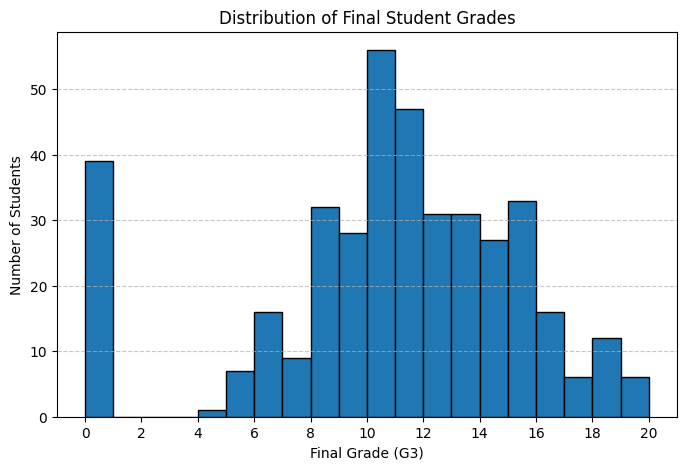

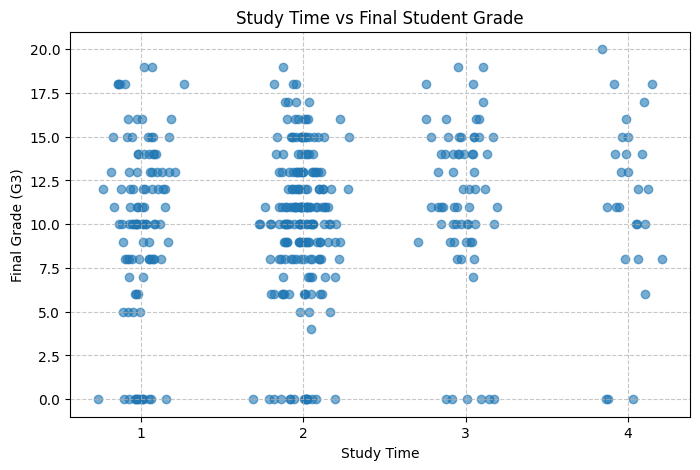

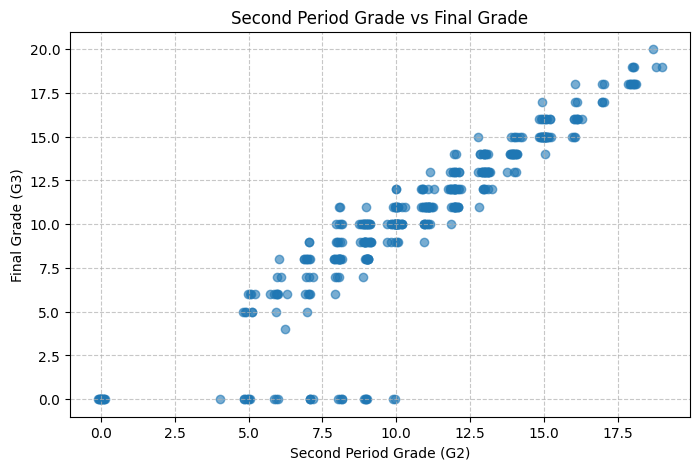

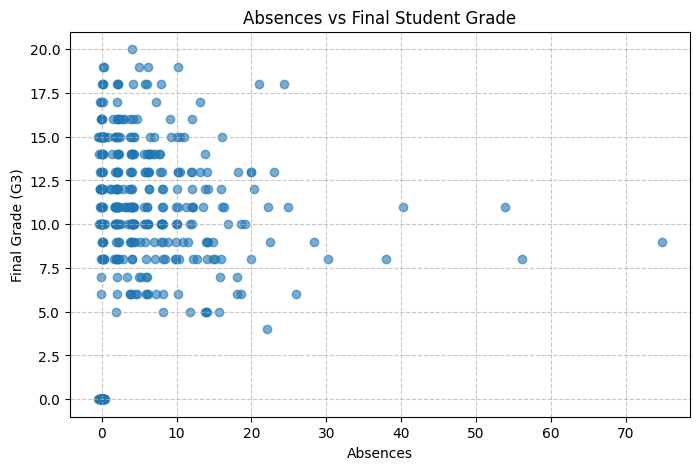

In [39]:
# -----------------------------
# 4. Data Visualization
# -----------------------------

# Final Grade Distribution
plt.figure(figsize=(8, 5))
plt.hist(df["G3"], bins=range(0, 21), edgecolor='black') # Adjusted bins for more detail

plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Student Grades")
plt.xticks(range(0, 21, 2)) # Set x-ticks for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Study Time vs Final Grade
plt.figure(figsize=(8, 5))
# Add jitter to 'studytime' and transparency to points
plt.scatter(df["studytime"] + np.random.normal(0, 0.1, df.shape[0]), df["G3"], alpha=0.6)

plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.title("Study Time vs Final Student Grade")
plt.xticks(range(1, 5)) # Ensure x-ticks align with studytime categories
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# G2 vs Final Grade
plt.figure(figsize=(8, 5))
# Add jitter to 'G2' and transparency to points
plt.scatter(df["G2"] + np.random.normal(0, 0.1, df.shape[0]), df["G3"], alpha=0.6)

plt.xlabel("Second Period Grade (G2)")
plt.ylabel("Final Grade (G3)")
plt.title("Second Period Grade vs Final Grade")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# Absences vs Final Grade
plt.figure(figsize=(8, 5))
# Add jitter to 'absences' and transparency to points
plt.scatter(df["absences"] + np.random.normal(0, 0.2, df.shape[0]), df["G3"], alpha=0.6)

plt.xlabel("Absences")
plt.ylabel("Final Grade (G3)")
plt.title("Absences vs Final Student Grade")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [40]:
# -----------------------------
# Convert DataFrame to Excel File
# -----------------------------

output_excel_file = "Student_grades.xlsx"
df.to_excel(output_excel_file, index=False)

print(f"DataFrame successfully converted and saved to '{output_excel_file}'")

DataFrame successfully converted and saved to 'Student_grades.xlsx'


In [41]:
# -----------------------------
# 5. Select Features and Target
# -----------------------------

X = df[
    [
        "studytime",
        "failures",
        "absences",
        "G1",
        "G2"
    ]
]

y = df["G3"]

In [42]:
# -----------------------------
# 6. Train-Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n========== TRAIN-TEST SPLIT ==========")
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


========== TRAIN-TEST SPLIT ==========
Training samples: 317
Testing samples : 80


In [43]:
# -----------------------------
# 7. Create Linear Regression Model
# -----------------------------

model = LinearRegression()


# -----------------------------
# 8. Train Model
# -----------------------------

model.fit(X_train, y_train)

print("\nLinear Regression model trained successfully!")


# -----------------------------
# 9. Prediction
# -----------------------------

y_pred = model.predict(X_test)



Linear Regression model trained successfully!


In [44]:
# -----------------------------
# 10. Model Evaluation
# -----------------------------

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\n========================================")
print("       MODEL EVALUATION RESULTS")
print("========================================")

print("R² Score            :", round(r2, 4))
print("Mean Absolute Error :", round(mae, 4))

print("========================================")


# -----------------------------
# 11. Actual vs Predicted
# -----------------------------

comparison = pd.DataFrame({
    "Actual G3": y_test.values,
    "Predicted G3": y_pred
})

print("\n========== ACTUAL VS PREDICTED ==========")
print(comparison.head(10))



       MODEL EVALUATION RESULTS
R² Score            : 0.8708
Mean Absolute Error : 1.0013

========== ACTUAL VS PREDICTED ==========
   Actual G3  Predicted G3
0          9      8.594553
1          8      7.493293
2         12     12.708301
3         15     15.112924
4          5      4.510220
5         11     11.005359
6         14     11.891859
7         10      6.528910
8          0     -2.199468
9         10      9.695730


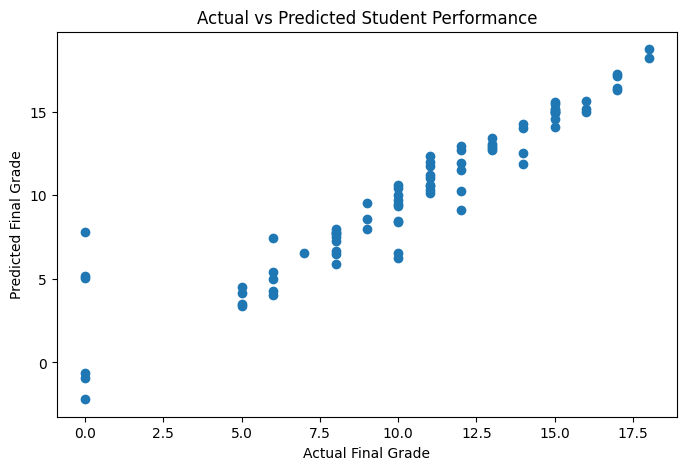


========== MODEL COEFFICIENTS ==========
     Feature  Coefficient
0  studytime    -0.115075
1   failures    -0.371783
2   absences     0.037321
3         G1     0.144659
4         G2     0.990727

Model Intercept: -1.6923383992636154


In [45]:
# -----------------------------
# 12. Visualization of Predictions
# -----------------------------

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Actual vs Predicted Student Performance")

plt.show()

# -----------------------------
# 13. Model Coefficients
# -----------------------------

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\n========== MODEL COEFFICIENTS ==========")
print(coefficients)

print("\nModel Intercept:", model.intercept_)



In [46]:
# -----------------------------
# 14. Predict New Student
# -----------------------------

new_student = pd.DataFrame({
    "studytime": [3],
    "failures": [0],
    "absences": [5],
    "G1": [12],
    "G2": [13]
})

new_prediction = model.predict(new_student)

print("\n========================================")
print("       NEW STUDENT PREDICTION")
print("========================================")

print("Study Time        :", new_student["studytime"].iloc[0])
print("Failures          :", new_student["failures"].iloc[0])
print("Absences          :", new_student["absences"].iloc[0])
print("G1                :", new_student["G1"].iloc[0])
print("G2                :", new_student["G2"].iloc[0])

print("\nPredicted Final Grade:",
      round(new_prediction[0], 2))

print("========================================")


       NEW STUDENT PREDICTION
Study Time        : 3
Failures          : 0
Absences          : 5
G1                : 12
G2                : 13

Predicted Final Grade: 12.76
